## Generate Sky Mask

#### 确定mask不同类别像素值
原数据 gt_image下存储 可通行区域，不可达区域，不可通行区域，其中不可达区域可以当作天空的掩码，首先确定 可通行区域为255，不可通行区域为0， 不可达区域为128

唯一像素值: [  0 128 255]


(-0.5, 1279.5, 719.5, -0.5)

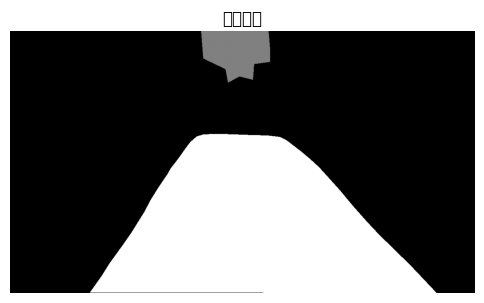

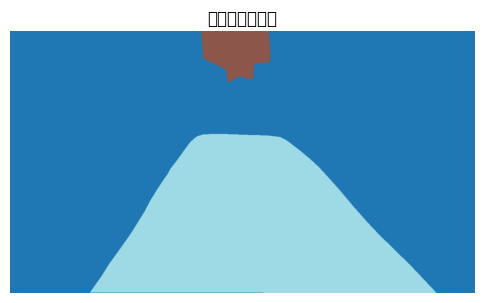

In [6]:
from pathlib import Path
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# TODO: update this path to the mask image you want to inspect
mask_path = Path("/home/minchen/data/wangshuo/datasets/dggt/orad/train/y2021_0223_1808/gt_image/1620323324363_fillcolor.png")

mask = np.array(Image.open(mask_path))

plt.figure(figsize=(6, 6))
plt.title("原始遮罩")
plt.imshow(mask, cmap="gray")
plt.axis("off")

unique_values = np.unique(mask)
print("唯一像素值:", unique_values)

# Create a color for each index so we can visualize unreachable regions
colormap = plt.get_cmap("tab20", len(unique_values))
color_mask = np.zeros(mask.shape + (3,), dtype=np.uint8)
for idx, value in enumerate(unique_values):
    color = np.array(colormap(idx)[:3]) * 255
    color_mask[mask == value] = color.astype(np.uint8)

plt.figure(figsize=(6, 6))
plt.title("彩色索引可视化")
plt.imshow(color_mask)
plt.axis("off")


#### Generate sky mask by gt image annotations

In [1]:
from pathlib import Path
import numpy as np
from PIL import Image
from tqdm.auto import tqdm

train_root = Path("/data20t/wangshuo/dggt/orad/testing")  # update to the directory that contains scene folders
if not train_root.exists():
    raise SystemExit(f"train root {train_root} does not exist")

scene_dirs = [d for d in sorted(train_root.iterdir()) if d.is_dir()]
for scene_dir in tqdm(scene_dirs, desc="scenes", unit="scene"):
    gt_image_dir = scene_dir / "gt_image"
    if not gt_image_dir.exists():
        print(f"skipping {scene_dir.name}: gt_image missing")
        continue

    sky_dir = scene_dir / "sky_masks"
    sky_dir.mkdir(exist_ok=True)

    mask_files = sorted(gt_image_dir.glob("*.png"))
    if not mask_files:
        print(f"skipping {scene_dir.name}: no mask pngs found")
        continue

    for mask_path in tqdm(mask_files, desc=f"{scene_dir.name}", leave=False, unit="mask"):
        mask = np.array(Image.open(mask_path))
        sky_mask = np.where(mask == 128, 255, 0).astype(np.uint8)
        sky_path = sky_dir / mask_path.name
        Image.fromarray(sky_mask).save(sky_path)
    tqdm.write(f"saved sky masks for {scene_dir.name} ({len(mask_files)} files)")

scenes:   0%|          | 0/30 [00:00<?, ?scene/s]

x0613_1627:   0%|          | 0/380 [00:00<?, ?mask/s]

saved sky masks for x0613_1627 (380 files)
skipping x2021_0222_1733: gt_image missing


x2021_0222_1737:   0%|          | 0/303 [00:00<?, ?mask/s]

saved sky masks for x2021_0222_1737 (303 files)


...

saved sky masks for y2021_0403_1736 (397 files)


y2021_0403_1744:   0%|          | 0/468 [00:00<?, ?mask/s]

saved sky masks for y2021_0403_1744 (468 files)


y2021_0403_1858:   0%|          | 0/528 [00:00<?, ?mask/s]

saved sky masks for y2021_0403_1858 (528 files)


## Dynamic Mask

DGGT由于对低频率数据进行了插值得到高频率的数据，对密集标注也进行了插值，因此需要使用segformer进一步分割来refine mask，由于ORAD频率在10HZ左右，并且具有准确的密集标注，直接将gt_image_multi_seg的json中的运动物体进行dynamic_masks的生成

In [2]:
import json
from pathlib import Path

import cv2
import numpy as np
from PIL import Image
from tqdm.auto import tqdm

train_root = Path("/data20t/wangshuo/dggt/orad/testing")
if not train_root.exists():
    raise SystemExit(f"train root {train_root} does not exist")

IMAGE_SIZE = (1280, 720)
scene_dirs = [d for d in sorted(train_root.iterdir()) if d.is_dir()]
dynamic_classes = {"car", "people"}
for scene_dir in tqdm(scene_dirs, desc="scenes", unit="scene"):
    seg_dir = scene_dir / "gt_image_multi_seg"
    if not seg_dir.exists():
        print(f"skipping {scene_dir.name}: gt_image_multi_seg missing")
        continue

    dynamic_dir = scene_dir / "dynamic_masks"
    dynamic_dir.mkdir(exist_ok=True)

    json_files = sorted(seg_dir.glob("*.json"))
    if not json_files:
        print(f"skipping {scene_dir.name}: no json labels")
        continue

    for json_path in tqdm(json_files, desc=f"{scene_dir.name}", leave=False, unit="json"):
        spec = json.loads(json_path.read_text(encoding="utf-8"))
        width, height = IMAGE_SIZE

        mask = np.zeros((height, width), dtype=np.uint8)
        for shape in spec.get("shapes", []):
            label = shape.get("label") or shape.get("tag")
            if label not in dynamic_classes:
                continue

            points = np.array(shape.get("points", []), dtype=np.int32)
            if points.size == 0:
                continue
            points = points.reshape((-1, 1, 2))
            cv2.fillPoly(mask, [points], 255)

        output_path = dynamic_dir / f"{json_path.stem}.png"
        Image.fromarray(mask).save(output_path)
    tqdm.write(f"saved dynamic masks for {scene_dir.name} ({len(json_files)} jsons)")

scenes:   0%|          | 0/30 [00:00<?, ?scene/s]

x0613_1627:   0%|          | 0/380 [00:00<?, ?json/s]

saved dynamic masks for x0613_1627 (380 jsons)


x2021_0222_1733:   0%|          | 0/307 [00:00<?, ?json/s]

saved dynamic masks for x2021_0222_1733 (307 jsons)


...

saved dynamic masks for y2021_0403_1736 (397 jsons)


y2021_0403_1744:   0%|          | 0/468 [00:00<?, ?json/s]

saved dynamic masks for y2021_0403_1744 (468 jsons)


y2021_0403_1858:   0%|          | 0/528 [00:00<?, ?json/s]

saved dynamic masks for y2021_0403_1858 (528 jsons)


## 可视化mask效果图

random seed: 1770016470
scene: y2021_0403_1744
image: 1620348086754.png


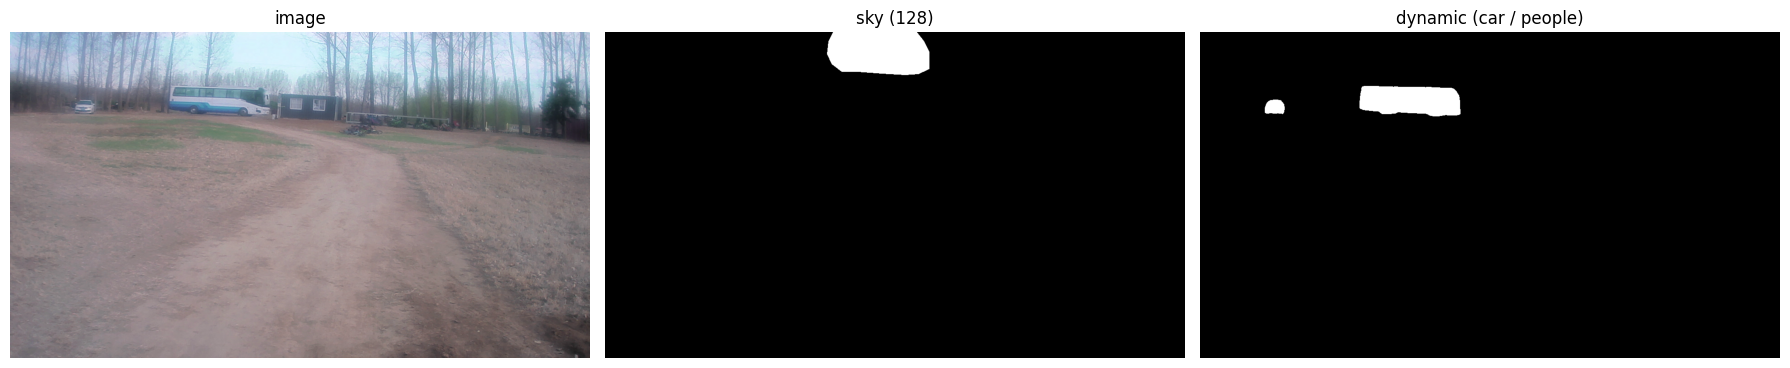

In [ ]:
import json
import time
import random
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from sympy import false

# ---------------- config ----------------
train_root = Path("/data20t/wangshuo/dggt/orad/training")
IMAGE_SIZE = (1280, 720)
SKY_LABEL = 255
dynamic_classes = {"car", "people"}
# dynamic_classes = {"rock"}

assert train_root.exists(), "train root does not exist"

# 随机种子：每次运行都不一样
seed = int(time.time())
random.seed(seed)
np.random.seed(seed)
print(f"random seed: {seed}")

# ---------------- helper ----------------
def load_mask(path: Path):
    return np.array(Image.open(path))

def exist_dynamic(spec):

    exist = False
    for shape in spec.get("shapes", []):
        label = shape.get("tag")
        if label in dynamic_classes:
            exist = True

    return exist

# ---------------- search ----------------
match = None
scene_dirs = [d for d in train_root.iterdir() if d.is_dir()]
random.shuffle(scene_dirs)

for scene_dir in scene_dirs:
    gt_dir = scene_dir / "sky_masks"
    seg_dir = scene_dir / "gt_image_multi_seg"
    img_dir = scene_dir / "image_data"
    dynamic_dir = scene_dir / "dynamic_masks"
    imgs = list(img_dir.glob("*.png"))
    random.shuffle(imgs)

    for img_path in imgs:
        mask_path = gt_dir / f"{img_path.stem}_fillcolor.png"
        json_path = seg_dir / f"{img_path.stem}.json"
        dynamic_mask_path = dynamic_dir / f"{img_path.stem}.png"

        mask = load_mask(mask_path)
        if not np.any(mask == SKY_LABEL):
            continue

        spec = json.loads(json_path.read_text(encoding="utf-8"))
        if exist_dynamic(spec):
            dynamic_mask = load_mask(dynamic_mask_path)
        else:
            continue

        match = {
            "scene": scene_dir,
            "image": img_path,
            "gt": mask_path,
            "json": json_path,
            "sky": (mask == SKY_LABEL).astype(np.uint8) * 255,
            "dynamic": dynamic_mask,
        }
        break

    if match:
        break

# ---------------- visualize ----------------
if not match:
    print("no combined sky + dynamic image found")
else:
    print(f"scene: {match['scene'].name}")
    print(f"image: {match['image'].name}")

    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    axes[0].imshow(Image.open(match["image"]))
    axes[0].set_title("image")

    axes[1].imshow(match["sky"], cmap="gray")
    axes[1].set_title("sky (128)")

    axes[2].imshow(match["dynamic"], cmap="gray")
    axes[2].set_title("dynamic (car / people)")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


## 法线估计

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class SNE(nn.Module):
    """SNE takes depth and camera intrinsic parameters as input,
    and outputs normal estimations.
    """
    def __init__(self):
        super(SNE, self).__init__()

    def forward(self, depth, camParam):
        h,w = depth.size()
        v_map, u_map = torch.meshgrid(torch.arange(h), torch.arange(w))
        v_map = v_map.type(torch.float32)
        u_map = u_map.type(torch.float32)

        Z = depth   # h, w
        Y = Z.mul((v_map - camParam[1,2])) / camParam[0,0]  # h, w
        X = Z.mul((u_map - camParam[0,2])) / camParam[0,0]  # h, w
        # half part
        #Z[Y <= 0] = 0
        #Y[Y <= 0] = 0 
        Z[torch.isnan(Z)] = 0
        D = torch.div(torch.ones(h, w), Z)  # h, w

        Gx = torch.tensor([[0,0,0],[-1,0,1],[0,0,0]], dtype=torch.float32)
        Gy = torch.tensor([[0,-1,0],[0,0,0],[0,1,0]], dtype=torch.float32)

        Gu = F.conv2d(D.view(1,1,h,w), Gx.view(1,1,3,3), padding=1)
        Gv = F.conv2d(D.view(1,1,h,w), Gy.view(1,1,3,3), padding=1)

        nx_t = Gu * camParam[0,0]   # 1, 1, h, w
        ny_t = Gv * camParam[1,1]   # 1, 1, h, w

        phi = torch.atan(torch.div(ny_t, nx_t)) + torch.ones([1,1,h,w])*3.141592657
        a = torch.cos(phi)
        b = torch.sin(phi)

        diffKernelArray = torch.tensor([[-1, 0, 0, 0, 1, 0, 0, 0, 0],
                                        [ 0,-1, 0, 0, 1, 0, 0, 0, 0],
                                        [ 0, 0,-1, 0, 1, 0, 0, 0, 0],
                                        [ 0, 0, 0,-1, 1, 0, 0, 0, 0],
                                        [ 0, 0, 0, 0, 1,-1, 0, 0, 0],
                                        [ 0, 0, 0, 0, 1, 0,-1, 0, 0],
                                        [ 0, 0, 0, 0, 1, 0, 0,-1, 0],
                                        [ 0, 0, 0, 0, 1, 0, 0, 0,-1]], dtype=torch.float32)

        sum_nx = torch.zeros((1,1,h,w), dtype=torch.float32)
        sum_ny = torch.zeros((1,1,h,w), dtype=torch.float32)
        sum_nz = torch.zeros((1,1,h,w), dtype=torch.float32)

        for i in range(8):
            diffKernel = diffKernelArray[i].view(1,1,3,3)
            X_d = F.conv2d(X.view(1,1,h,w), diffKernel, padding=1)
            Y_d = F.conv2d(Y.view(1,1,h,w), diffKernel, padding=1)
            Z_d = F.conv2d(Z.view(1,1,h,w), diffKernel, padding=1)

            nz_i = torch.div((torch.mul(nx_t, X_d) + torch.mul(ny_t, Y_d)), Z_d)
            norm = torch.sqrt(torch.mul(nx_t, nx_t) + torch.mul(ny_t, ny_t) + torch.mul(nz_i, nz_i))
            nx_t_i = torch.div(nx_t, norm)
            ny_t_i = torch.div(ny_t, norm)
            nz_t_i = torch.div(nz_i, norm)

            nx_t_i[torch.isnan(nx_t_i)] = 0
            ny_t_i[torch.isnan(ny_t_i)] = 0
            nz_t_i[torch.isnan(nz_t_i)] = 0

            sum_nx = sum_nx + nx_t_i
            sum_ny = sum_ny + ny_t_i
            sum_nz = sum_nz + nz_t_i

        theta = -torch.atan(torch.div((torch.mul(sum_nx, a) + torch.mul(sum_ny, b)), sum_nz))
        nx = torch.mul(torch.sin(theta), torch.cos(phi))
        ny = torch.mul(torch.sin(theta), torch.sin(phi))
        nz = torch.cos(theta)

        nx[torch.isnan(nz)] = 0
        ny[torch.isnan(nz)] = 0
        nz[torch.isnan(nz)] = -1

        sign = torch.ones((1,1,h,w), dtype=torch.float32)
        sign[ny > 0] = -1

        nx = torch.mul(nx, sign).squeeze(dim=0)
        ny = torch.mul(ny, sign).squeeze(dim=0)
        nz = torch.mul(nz, sign).squeeze(dim=0)

        return torch.cat([nx, ny, nz], dim=0)